# ResNet101

✅ Đã load weights từ model_state_dict
✅ Đã load g_min/g_max từ checkpoint.

✅ FILE: Sample_2022-06-09.npz | NSE: 0.7492 | KGE: 0.6944


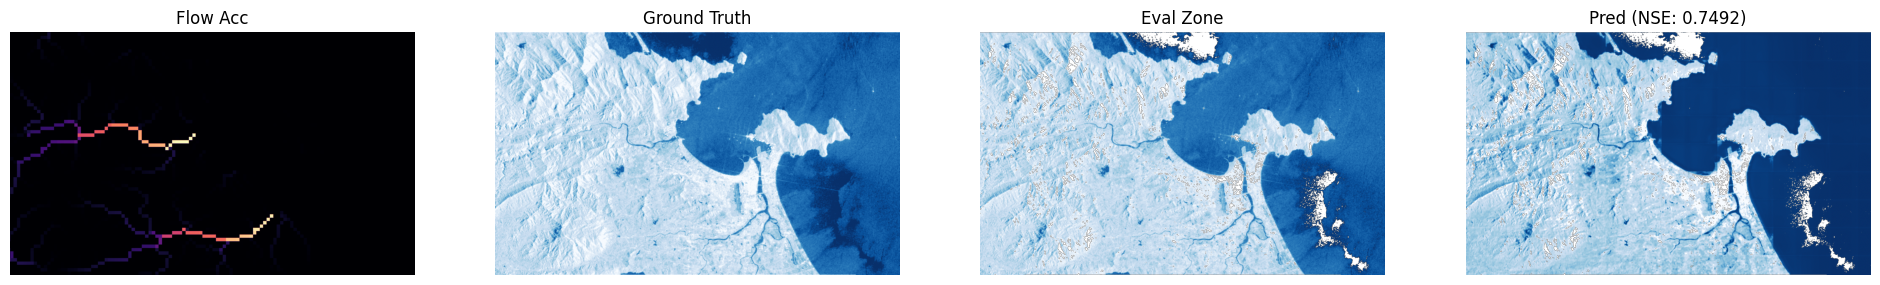

🚀 Bắt đầu batch test 85 file...


100%|██████████| 85/85 [02:31<00:00,  1.78s/it]


KẾT QUẢ TRUNG BÌNH:
NSE    0.538742
KGE    0.719909
MAE    0.126901
dtype: float64


In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from tqdm import tqdm
from sklearn.metrics import r2_score
from skimage.restoration import denoise_nl_means, estimate_sigma

# ================= CONFIG =================
MODEL_INPUT_PATH = r"E:\FPT\DAP391m\model\best_model_resnet101.pth"
FOLDER_PATH = r"E:\FPT\DAP391m\model\outputres101\test" # Thư mục chứa file .npz
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.15

# ================= 1. MODEL ARCHITECTURE (Tuned for ResNet101) =================
class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dims, out_dims, 1, bias=False)
        self.conv2 = nn.Conv2d(in_dims, out_dims, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_dims, out_dims, 3, padding=12, dilation=12, bias=False)
        self.conv_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dims, out_dims, 1, bias=False))
        self.fuse = nn.Sequential(nn.Conv2d(out_dims*4, out_dims, 1), nn.BatchNorm2d(out_dims), nn.ReLU())

    def forward(self, x):
        h, w = x.shape[-2:]
        res = [
            self.conv1(x),
            self.conv2(x),
            self.conv3(x),
            torch.nn.functional.interpolate(self.conv_pool(x), size=(h,w), mode='bilinear', align_corners=True)
        ]
        return self.fuse(torch.cat(res, dim=1))

class FlexibleFloodModel(nn.Module):
    def __init__(self, encoder_name='resnet101'):
        super().__init__()
        self.base = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=8,
            classes=1,
            decoder_attention_type='scse' # Tắt SCSE để khớp với model đã train của bạn
        )
        # Tự động lấy số channels cuối cùng của ResNet101 (2048)
        ch = self.base.encoder.out_channels[-1]
        self.aspp = ASPP(ch, ch)

    def forward(self, x):
        feats = self.base.encoder(x)
        feats[-1] = self.aspp(feats[-1])
        dec = self.base.decoder(feats)
        return self.base.segmentation_head(dec)

# ================= 2. UTILS & METRICS =================
def calculate_masked_metrics(y_true, y_pred):
    mask = (y_true > 0.001) & (y_true < 0.999) 
    if not np.any(mask): return 0, 0, 0, 0
    
    y_t, y_p = y_true[mask], y_pred[mask]
    mae = np.mean(np.abs(y_t - y_p))
    nse = 1 - (np.sum((y_t - y_p)**2) / (np.sum((y_t - np.mean(y_t))**2) + 1e-10))
    r2 = r2_score(y_t, y_p)
    
    # KGE
    r = np.corrcoef(y_t, y_p)[0, 1] if np.std(y_p) > 0 else 0
    alpha = np.std(y_p) / (np.std(y_t) + 1e-10)
    beta = np.mean(y_p) / (np.mean(y_t) + 1e-10)
    kge = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    return mae, r2, nse, kge

def sota_denoise(y_pred):
    img = y_pred.astype(np.float64)
    sigma_est = np.mean(estimate_sigma(img, channel_axis=None))
    denoised = denoise_nl_means(img, h=0.8 * sigma_est, fast_mode=True, patch_size=5, patch_distance=6)
    return denoised

def get_global_stats(folder_path, files):
    all_min, all_max = [], []
    print("⏳ Đang tính toán thông số chuẩn hóa...")
    for f_name in random.sample(files, min(50, len(files))):
        data = np.load(os.path.join(folder_path, f_name))
        x = data['x']
        all_min.append(x.min(axis=(1, 2)))
        all_max.append(x.max(axis=(1, 2)))
    return np.array(all_min).min(axis=0), np.array(all_max).max(axis=0)

# ================= 3. INFERENCE ENGINE (Tuned) =================
def smart_inference_resnet(model, test_files, folder_path, g_min, g_max):
    # Chọn file ngẫu nhiên để demo
    file_name = random.choice(test_files)
    data = np.load(os.path.join(folder_path, file_name))
    x_full = torch.from_numpy(data['x']).float().to(DEVICE) 
    y_true = data['y']
    h, w = y_true.shape

    # Tensors chuẩn hóa
    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)

    # Padding
    pad_h = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE
    pad_w = (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
    x_padded = F.pad(x_full, (0, pad_w, 0, pad_h), mode='reflect')
    h_p, w_p = x_padded.shape[1:]

    y_pred_sum = np.zeros((h_p, w_p))
    y_count = np.zeros((h_p, w_p))

    # Sliding Window
    with torch.no_grad():
        for i in range(0, h_p - PATCH_SIZE + 1, STRIDE):
            for j in range(0, w_p - PATCH_SIZE + 1, STRIDE):
                patch = x_padded[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE].unsqueeze(0)
                patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                
                logits = model(patch)
                pred = torch.sigmoid(logits).squeeze().cpu().numpy()
                y_pred_sum[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += pred
                y_count[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 1

    # Post-process
    y_pred_final = np.divide(y_pred_sum, y_count, out=np.zeros_like(y_pred_sum), where=y_count!=0)
    y_pred_final = y_pred_final[:h, :w]
    y_pred_final = sota_denoise(y_pred_final)
    y_pred_final[y_pred_final < THRESHOLD] = 0
    
    # Min-Max Stretching (Cứu NSE)
    if y_pred_final.max() > 0:
        y_pred_final = (y_pred_final - y_pred_final.min()) / (y_pred_final.max() - y_pred_final.min() + 1e-7)
    y_pred_final = np.clip(y_pred_final, 0, 1)

    # Metrics & Plot
    mae, r2, nse, kge = calculate_masked_metrics(y_true, y_pred_final)
    print(f"\n✅ FILE: {file_name} | NSE: {nse:.4f} | KGE: {kge:.4f}")

    # Visualization (Giống snippet bạn gửi)
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(data['x'][7], cmap='magma'); axes[0].set_title("Flow Acc"); axes[0].axis('off')
    axes[1].imshow(y_true, cmap='Blues'); axes[1].set_title("Ground Truth"); axes[1].axis('off')
    eval_mask = (y_true > 0.001) & (y_true < 0.999)
    axes[2].imshow(np.where(eval_mask, y_true, np.nan), cmap='Blues'); axes[2].set_title("Eval Zone"); axes[2].axis('off')
    im = axes[3].imshow(np.where(eval_mask, y_pred_final, np.nan), cmap='Blues'); axes[3].set_title(f"Pred (NSE: {nse:.4f})"); axes[3].axis('off')
    plt.show()

# ================= 4. BATCH EVALUATION =================
def batch_evaluate_resnet(model, test_files, folder_path, g_min, g_max):
    results = []
    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)
    
    print(f"🚀 Bắt đầu batch test {len(test_files)} file...")
    for file_name in tqdm(test_files):
        try:
            data = np.load(os.path.join(folder_path, file_name))
            x_full = torch.from_numpy(data['x']).float().to(DEVICE)
            y_true = data['y']
            h, w = y_true.shape

            # Inference (Fast - no stride if possible, but keeping consistency)
            patch_size = 256
            pad_h, pad_w = (patch_size - h % patch_size) % patch_size, (patch_size - w % patch_size) % patch_size
            x_p = F.pad(x_full, (0, pad_w, 0, pad_h), mode='reflect')
            
            # Đơn giản hóa Sliding window cho batch test (stride = patch_size) để nhanh hơn
            y_pred_full = np.zeros(x_p.shape[1:])
            with torch.no_grad():
                for i in range(0, x_p.shape[1] - patch_size + 1, patch_size):
                    for j in range(0, x_p.shape[2] - patch_size + 1, patch_size):
                        patch = x_p[:, i:i+patch_size, j:j+patch_size].unsqueeze(0)
                        patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                        y_pred_full[i:i+patch_size, j:j+patch_size] = torch.sigmoid(model(patch)).squeeze().cpu().numpy()
            
            y_p = y_pred_full[:h, :w]
            y_p = sota_denoise(y_p)
            y_p[y_p < THRESHOLD] = 0
            if y_p.max() > 0: y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
            
            mae, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
            results.append({'file': file_name, 'NSE': nse, 'KGE': kge, 'MAE': mae})
        except Exception as e: print(f"Error {file_name}: {e}")
    
    return pd.DataFrame(results)

# ================= 5. RUN ALL =================
if __name__ == "__main__":
    # Khởi tạo model
    model = FlexibleFloodModel(encoder_name='resnet101').to(DEVICE)
    
    # Load Checkpoint an toàn
    checkpoint = torch.load(MODEL_INPUT_PATH, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("✅ Đã load weights từ model_state_dict")
    else:
        model.load_state_dict(checkpoint)
        print("✅ Đã load weights trực tiếp")
    model.eval()

    # Chuẩn bị file test
    all_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.npz')]
    
    # Lấy g_min, g_max từ checkpoint hoặc tính mới
    if isinstance(checkpoint, dict) and 'g_min' in checkpoint:
        g_min, g_max = checkpoint['g_min'], checkpoint['g_max']
        print("✅ Đã load g_min/g_max từ checkpoint.")
    else:
        g_min, g_max = get_global_stats(FOLDER_PATH, all_files)

    # 1. Chạy thử 1 file
    smart_inference_resnet(model, all_files, FOLDER_PATH, g_min, g_max)

    # 2. Chạy toàn bộ tập test
    df_final = batch_evaluate_resnet(model, all_files, FOLDER_PATH, g_min, g_max)
    print("\nKẾT QUẢ TRUNG BÌNH:")
    print(df_final[['NSE', 'KGE', 'MAE']].mean())

# Mit_b3 


✨ MiT-B3 Result | FILE: Sample_2021-06-19.npz | NSE: 0.6201 | KGE: 0.7819


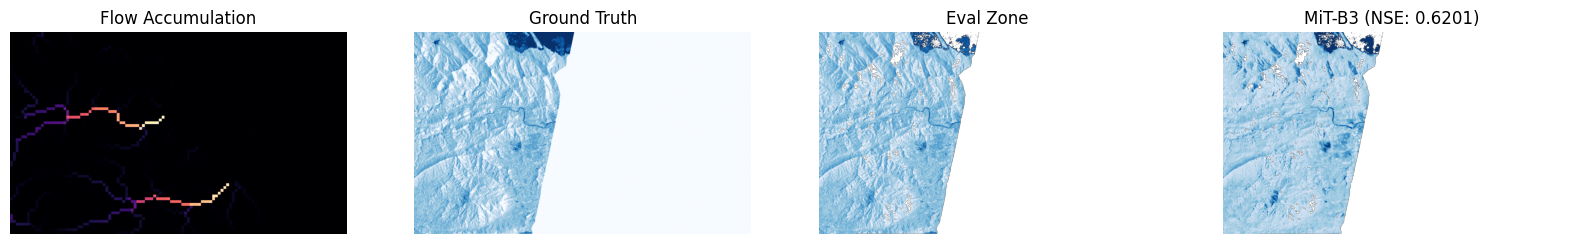

🚀 MiT-B3: Đang đánh giá 85 file...


100%|██████████| 85/85 [02:41<00:00,  1.90s/it]


📊 MI-B3 SUMMARY:
NSE    0.555395
KGE    0.721549
MAE    0.126119
dtype: float64


In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from tqdm import tqdm
from sklearn.metrics import r2_score
from skimage.restoration import denoise_nl_means, estimate_sigma

# ================= CONFIG =================
MODEL_INPUT_PATH = r"E:\FPT\DAP391m\model\best_model_mit_b3.pth" 
FOLDER_PATH = r"E:\FPT\DAP391m\model\output_mitb3\test" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.15

# ================= 1. MODEL ARCHITECTURE (Tuned for MiT-B3) =================
class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dims, out_dims, 1, bias=False)
        self.conv2 = nn.Conv2d(in_dims, out_dims, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_dims, out_dims, 3, padding=12, dilation=12, bias=False)
        self.conv_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dims, out_dims, 1, bias=False))
        self.fuse = nn.Sequential(nn.Conv2d(out_dims*4, out_dims, 1), nn.BatchNorm2d(out_dims), nn.ReLU())

    def forward(self, x):
        h, w = x.shape[-2:]
        res = [
            self.conv1(x),
            self.conv2(x),
            self.conv3(x),
            torch.nn.functional.interpolate(self.conv_pool(x), size=(h,w), mode='bilinear', align_corners=True)
        ]
        return self.fuse(torch.cat(res, dim=1))

class FlexibleFloodModel(nn.Module):
    def __init__(self, encoder_name='mit_b3'): # Đổi về mit_b3
        super().__init__()
        self.base = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=8,
            classes=1,
            decoder_attention_type= None # Bật SCSE cho MiT-B3
        )
        # MiT-B3 có out_channels lớp cuối khác ResNet, ta lấy tự động:
        ch = self.base.encoder.out_channels[-1]
        self.aspp = ASPP(ch, ch)

    def forward(self, x):
        feats = self.base.encoder(x)
        feats[-1] = self.aspp(feats[-1])
        dec = self.base.decoder(feats)
        return self.base.segmentation_head(dec)

# ================= 2. UTILS & METRICS =================
def calculate_masked_metrics(y_true, y_pred):
    mask = (y_true > 0.001) & (y_true < 0.999) 
    if not np.any(mask): return 0, 0, 0, 0
    
    y_t, y_p = y_true[mask], y_pred[mask]
    mae = np.mean(np.abs(y_t - y_p))
    nse = 1 - (np.sum((y_t - y_p)**2) / (np.sum((y_t - np.mean(y_t))**2) + 1e-10))
    r2 = r2_score(y_t, y_p)
    
    r = np.corrcoef(y_t, y_p)[0, 1] if np.std(y_p) > 0 else 0
    alpha = np.std(y_p) / (np.std(y_t) + 1e-10)
    beta = np.mean(y_p) / (np.mean(y_t) + 1e-10)
    kge = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    return mae, r2, nse, kge

def sota_denoise(y_pred):
    img = y_pred.astype(np.float64)
    sigma_est = np.mean(estimate_sigma(img, channel_axis=None))
    return denoise_nl_means(img, h=0.8 * sigma_est, fast_mode=True, patch_size=5, patch_distance=6)

# ================= 3. INFERENCE ENGINE (Sliding Window) =================
def smart_inference_mit(model, test_files, folder_path, g_min, g_max):
    file_name = random.choice(test_files)
    data = np.load(os.path.join(folder_path, file_name))
    x_full = torch.from_numpy(data['x']).float().to(DEVICE) 
    y_true = data['y']
    h, w = y_true.shape

    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)

    pad_h, pad_w = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE, (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
    x_padded = F.pad(x_full, (0, pad_w, 0, pad_h), mode='reflect')
    h_p, w_p = x_padded.shape[1:]

    y_pred_sum = np.zeros((h_p, w_p))
    y_count = np.zeros((h_p, w_p))

    with torch.no_grad():
        for i in range(0, h_p - PATCH_SIZE + 1, STRIDE):
            for j in range(0, w_p - PATCH_SIZE + 1, STRIDE):
                patch = x_padded[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE].unsqueeze(0)
                patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                pred = torch.sigmoid(model(patch)).squeeze().cpu().numpy()
                y_pred_sum[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += pred
                y_count[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 1

    y_pred_final = np.divide(y_pred_sum, y_count, out=np.zeros_like(y_pred_sum), where=y_count!=0)[:h, :w]
    y_pred_final = sota_denoise(y_pred_final)
    y_pred_final[y_pred_final < THRESHOLD] = 0
    
    if y_pred_final.max() > 0:
        y_pred_final = (y_pred_final - y_pred_final.min()) / (y_pred_final.max() - y_pred_final.min() + 1e-7)
    y_pred_final = np.clip(y_pred_final, 0, 1)

    mae, r2, nse, kge = calculate_masked_metrics(y_true, y_pred_final)
    print(f"\n✨ MiT-B3 Result | FILE: {file_name} | NSE: {nse:.4f} | KGE: {kge:.4f}")

    # Plotting
    plt.figure(figsize=(20, 5))
    plt.subplot(141); plt.imshow(data['x'][7], cmap='magma'); plt.title("Flow Accumulation"); plt.axis('off')
    plt.subplot(142); plt.imshow(y_true, cmap='Blues'); plt.title("Ground Truth"); plt.axis('off')
    plt.subplot(143); plt.imshow(np.where((y_true > 0.001) & (y_true < 0.999), y_true, np.nan), cmap='Blues'); plt.title("Eval Zone"); plt.axis('off')
    plt.subplot(144); plt.imshow(np.where((y_true > 0.001) & (y_true < 0.999), y_pred_final, np.nan), cmap='Blues'); plt.title(f"MiT-B3 (NSE: {nse:.4f})"); plt.axis('off')
    plt.show()

# ================= 4. BATCH EVALUATION =================
def batch_evaluate_mit(model, test_files, folder_path, g_min, g_max):
    results = []
    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)
    
    print(f"🚀 MiT-B3: Đang đánh giá {len(test_files)} file...")
    for f_name in tqdm(test_files):
        try:
            data = np.load(os.path.join(folder_path, f_name))
            x_full = torch.from_numpy(data['x']).float().to(DEVICE)
            y_true = data['y']
            h, w = y_true.shape

            # Fast Inference for Batch (Stride = Patch_size)
            pad_h, pad_w = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE, (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
            x_p = F.pad(x_full, (0, pad_w, 0, pad_h), mode='reflect')
            y_pred_full = np.zeros(x_p.shape[1:])
            
            with torch.no_grad():
                for i in range(0, x_p.shape[1] - PATCH_SIZE + 1, PATCH_SIZE):
                    for j in range(0, x_p.shape[2] - PATCH_SIZE + 1, PATCH_SIZE):
                        patch = x_p[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE].unsqueeze(0)
                        patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                        y_pred_full[i:i+PATCH_SIZE, j:j+PATCH_SIZE] = torch.sigmoid(model(patch)).squeeze().cpu().numpy()
            
            y_p = y_pred_full[:h, :w]
            y_p = sota_denoise(y_p)
            y_p[y_p < THRESHOLD] = 0
            if y_p.max() > 0: y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
            
            mae, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
            results.append({'file': f_name, 'NSE': nse, 'KGE': kge, 'MAE': mae})
        except Exception as e: print(f"Error {f_name}: {e}")
    
    return pd.DataFrame(results)

# ================= 5. EXECUTION =================
if __name__ == "__main__":
    # Init MiT-B3
    model = FlexibleFloodModel(encoder_name='mit_b3').to(DEVICE)
    
    # Load Weights
    checkpoint = torch.load(MODEL_INPUT_PATH, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()

    all_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.npz')]
    
    # Get Normalization Stats
    if isinstance(checkpoint, dict) and 'g_min' in checkpoint:
        g_min, g_max = checkpoint['g_min'], checkpoint['g_max']
    else:
        # Hàm tính toán g_min/max nếu checkpoint không có
        all_min, all_max = [], []
        for f in random.sample(all_files, min(30, len(all_files))):
            d = np.load(os.path.join(FOLDER_PATH, f))['x']
            all_min.append(d.min(axis=(1,2))); all_max.append(d.max(axis=(1,2)))
        g_min, g_max = np.array(all_min).min(axis=0), np.array(all_max).max(axis=0)

    # Demo 1 file
    smart_inference_mit(model, all_files, FOLDER_PATH, g_min, g_max)

    # Batch evaluation
    df_results = batch_evaluate_mit(model, all_files, FOLDER_PATH, g_min, g_max)
    print("\n📊 MI-B3 SUMMARY:")
    print(df_results[['NSE', 'KGE', 'MAE']].mean())

# Visualize with resnet_101


d:\Application\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Đã load thành công model_state_dict
🚀 FILE: Sample_2020-05-07.npz | NSE: 0.4056 | MSE: 0.014303


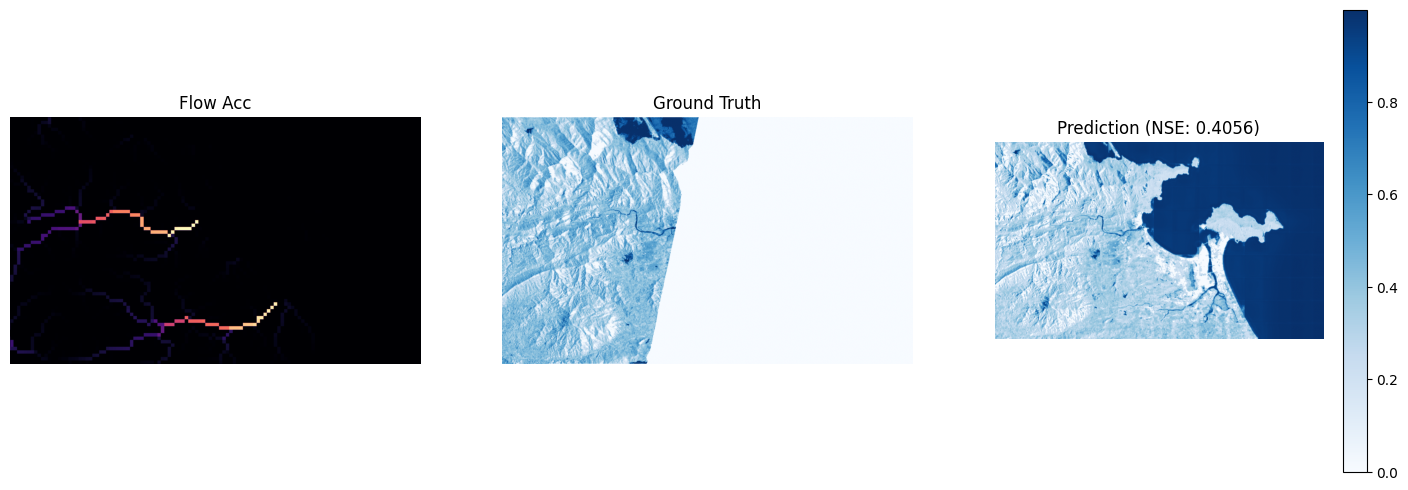

📊 Đang đánh giá 85 file bằng ResNet101...


100%|██████████| 85/85 [02:37<00:00,  1.85s/it]


✅ KẾT QUẢ TRUNG BÌNH RESNET101 (.PTH):
NSE    0.538742
MSE    0.025205
MAE    0.126901
KGE    0.719909
dtype: float64

🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):
                     file       MSE       NSE       MAE
73  Sample_2025-04-29.npz  0.008722  0.620737  0.070781
35  Sample_2022-03-10.npz  0.009250  0.616824  0.071652
17  Sample_2021-01-26.npz  0.009549  0.597377  0.071505
74  Sample_2025-05-17.npz  0.009558  0.561284  0.070868
20  Sample_2021-03-03.npz  0.010335  0.637047  0.079513


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import random
import segmentation_models_pytorch as smp
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from skimage.restoration import denoise_nl_means, estimate_sigma

# ================= CONFIG =================
MODEL_PATH = r"E:\\FPT\DAP391m\\model\best_model_resnet101.pth"
FOLDER_PATH = r"E:\\FPT\DAP391m\\model\\outputres101\\test"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = 256
STRIDE = 128
THRESHOLD = 0.15

# ================= 1. MODEL ARCHITECTURE =================
class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dims, out_dims, 1, bias=False)
        self.conv2 = nn.Conv2d(in_dims, out_dims, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_dims, out_dims, 3, padding=12, dilation=12, bias=False)
        self.conv_pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dims, out_dims, 1, bias=False))
        self.fuse = nn.Sequential(nn.Conv2d(out_dims*4, out_dims, 1), nn.BatchNorm2d(out_dims), nn.ReLU())

    def forward(self, x):
        h, w = x.shape[-2:]
        res = [
            self.conv1(x),
            self.conv2(x),
            self.conv3(x),
            torch.nn.functional.interpolate(self.conv_pool(x), size=(h,w), mode='bilinear', align_corners=True)
        ]
        return self.fuse(torch.cat(res, dim=1))

class FlexibleFloodModel(nn.Module):
    def __init__(self, encoder_name='resnet101'):
        super().__init__()
        self.base = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=8,
            classes=1,
            decoder_attention_type='scse' # Bật SCSE như model ResNet của bạn
        )
        ch = self.base.encoder.out_channels[-1]
        self.aspp = ASPP(ch, ch)

    def forward(self, x):
        feats = self.base.encoder(x)
        feats[-1] = self.aspp(feats[-1])
        dec = self.base.decoder(feats)
        return self.base.segmentation_head(dec)

# ================= 2. UTILS & METRICS =================
def calculate_masked_metrics(y_true, y_pred):
    mask = (y_true > 0.001) & (y_true < 0.999) 
    if not np.any(mask): return 0, 0, 0, 0, 0, 0
    
    y_t, y_p = y_true[mask], y_pred[mask]
    mae = np.mean(np.abs(y_t - y_p))
    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    nse = 1 - (np.sum((y_t - y_p)**2) / (np.sum((y_t - np.mean(y_t))**2) + 1e-10))
    r2 = r2_score(y_t, y_p)
    
    # KGE
    r = np.corrcoef(y_t, y_p)[0, 1] if np.std(y_p) > 0 else 0
    alpha = np.std(y_p) / (np.std(y_t) + 1e-10)
    beta = np.mean(y_p) / (np.mean(y_t) + 1e-10)
    kge = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    return mae, mse, rmse, r2, nse, kge

def sota_denoise(y_pred):
    img = y_pred.astype(np.float64)
    sigma_est = np.mean(estimate_sigma(img, channel_axis=None))
    return denoise_nl_means(img, h=0.8 * sigma_est, fast_mode=True, patch_size=5, patch_distance=6)

# ================= 3. PYTORCH INFERENCE ENGINE =================
def smart_inference_resnet_pth(model, test_files, folder_path, g_min, g_max):
    file_name = random.choice(test_files)
    data = np.load(os.path.join(folder_path, file_name))
    x_full = torch.from_numpy(data['x']).float().to(DEVICE)
    y_true = data['y']
    h, w = y_true.shape

    # Normalize Tensors
    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)

    # Padding Reflective
    pad_h = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE
    pad_w = (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
    x_padded = F.pad(x_full.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect') # (1, 8, H_p, W_p)
    _, _, h_p, w_p = x_padded.shape

    y_pred_sum = np.zeros((h_p, w_p))
    y_count = np.zeros((h_p, w_p))

    model.eval()
    with torch.no_grad():
        for i in range(0, h_p - PATCH_SIZE + 1, STRIDE):
            for j in range(0, w_p - PATCH_SIZE + 1, STRIDE):
                patch = x_padded[:, :, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                
                output = model(patch)
                pred = torch.sigmoid(output).squeeze().cpu().numpy()
                
                y_pred_sum[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += pred
                y_count[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 1

    # Post-process
    y_p = np.divide(y_pred_sum, y_count, out=np.zeros_like(y_pred_sum), where=y_count!=0)[:h, :w]
    y_p = sota_denoise(y_p)
    y_p[y_p < THRESHOLD] = 0
    
    # Min-Max Stretching (Cứu NSE)
    if y_p.max() > 0:
        y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
    y_p = np.clip(y_p, 0, 1)

    # Metrics & Plot
    mae, mse, rmse, r2, nse, kge = calculate_masked_metrics(y_true, y_p)
    print(f"🚀 FILE: {file_name} | NSE: {nse:.4f} | MSE: {mse:.6f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(data['x'][7], cmap='magma'); axes[0].set_title("Flow Acc"); axes[0].axis('off')
    axes[1].imshow(y_true, cmap='Blues'); axes[1].set_title("Ground Truth"); axes[1].axis('off')
    im = axes[2].imshow(y_p, cmap='Blues'); axes[2].set_title(f"Prediction (NSE: {nse:.4f})"); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2])
    plt.show()

# ================= 4. BATCH EVALUATION =================
def batch_evaluate_resnet_pth(model, test_files, folder_path, g_min, g_max):
    results = []
    G_MIN = torch.from_numpy(g_min).float().view(1, 8, 1, 1).to(DEVICE)
    G_MAX = torch.from_numpy(g_max).float().view(1, 8, 1, 1).to(DEVICE)
    
    print(f"📊 Đang đánh giá {len(test_files)} file bằng ResNet101...")
    model.eval()
    for f_name in tqdm(test_files):
        try:
            data = np.load(os.path.join(folder_path, f_name))
            x_full = torch.from_numpy(data['x']).float().to(DEVICE).unsqueeze(0)
            y_true = data['y']
            h, w = y_true.shape

            # Fast window (Stride = Patch)
            pad_h, pad_w = (PATCH_SIZE - h % PATCH_SIZE) % PATCH_SIZE, (PATCH_SIZE - w % PATCH_SIZE) % PATCH_SIZE
            x_p = F.pad(x_full, (0, pad_w, 0, pad_h), mode='reflect')
            y_pred_full = np.zeros(x_p.shape[2:])

            with torch.no_grad():
                for i in range(0, x_p.shape[2] - PATCH_SIZE + 1, PATCH_SIZE):
                    for j in range(0, x_p.shape[3] - PATCH_SIZE + 1, PATCH_SIZE):
                        patch = x_p[:, :, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                        patch = (patch - G_MIN) / (G_MAX - G_MIN + 1e-7)
                        pred = torch.sigmoid(model(patch))
                        y_pred_full[i:i+PATCH_SIZE, j:j+PATCH_SIZE] = pred.squeeze().cpu().numpy()
            
            y_p = y_pred_full[:h, :w]
            y_p = sota_denoise(y_p)
            y_p[y_p < THRESHOLD] = 0
            if y_p.max() > 0: y_p = (y_p - y_p.min()) / (y_p.max() - y_p.min() + 1e-7)
            
            metrics = calculate_masked_metrics(y_true, y_p)
            results.append({'file': f_name, 'NSE': metrics[4], 'MSE': metrics[1], 'MAE': metrics[0], 'KGE': metrics[5]})
        except Exception as e:
            print(f"Lỗi {f_name}: {e}")
            
    return pd.DataFrame(results)

# ================= RUN =================
if __name__ == "__main__":
    # 1. Khởi tạo Model
    model = FlexibleFloodModel(encoder_name='resnet101').to(DEVICE)
    
    # 2. Load Checkpoint
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("✅ Đã load thành công model_state_dict")
    else:
        model.load_state_dict(checkpoint)
        print("✅ Đã load thành công state_dict")

    all_test_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.npz')]

    # 3. Stats chuẩn hóa (Ưu tiên lấy từ checkpoint)
    if isinstance(checkpoint, dict) and 'g_min' in checkpoint:
        g_min, g_max = checkpoint['g_min'], checkpoint['g_max']
    else:
        # Tính mẫu từ 30 file nếu không có
        mins, maxs = [], []
        for f in random.sample(all_test_files, min(30, len(all_test_files))):
            d = np.load(os.path.join(FOLDER_PATH, f))['x']
            mins.append(d.min(axis=(1,2))); maxs.append(d.max(axis=(1,2)))
        g_min, g_max = np.array(mins).min(axis=0), np.array(maxs).max(axis=0)

    # 4. Thực thi
    smart_inference_resnet_pth(model, all_test_files, FOLDER_PATH, g_min, g_max)
    
    df = batch_evaluate_resnet_pth(model, all_test_files, FOLDER_PATH, g_min, g_max)
    print("\n✅ KẾT QUẢ TRUNG BÌNH RESNET101 (.PTH):")
    print(df.mean(numeric_only=True))
    # Hiển thị Top 5 file có MSE thấp nhất (tốt nhất)
    print("\n🏆 TOP 5 FILES CÓ MSE THẤP NHẤT (CHÍNH XÁC NHẤT):")
    print(df.sort_values('MSE', ascending=True)[['file', 'MSE', 'NSE', 'MAE']].head(5))